# 04. EfficientNet-only

Четвертый эксперимент: обучаем модели только на эмбеддингах `effnet_feat_*` из `data_with_efficientnet_features.csv`. `answer` и `description` не попадают в матрицу признаков.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Загрузка данных

In [2]:
DATA_PATH = Path("../data_with_efficientnet_features.csv")
df = pd.read_csv(DATA_PATH)

effnet_cols = [col for col in df.columns if col.startswith("effnet_feat_")]
assert effnet_cols, "В датасете не найдены колонки effnet_feat_*"

print(f"Rows: {len(df)}")
print(f"EfficientNet features: {len(effnet_cols)}")
df[["id", "answer", "description", "difficulty"]].head()

Rows: 327
EfficientNet features: 1280


,id,answer,description,difficulty
0,1,брауни,Коричневая английская Е (читается как и) = Bro...,0.4303
1,2,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,0.4010
2,3,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,0.3736
3,4,подоконник,Под О Конь и К,0.2045
4,5,редактор,Красный актер = Red Actor,0.3675


## Матрица признаков без answer/description

В `X` попадают только числовые признаки EfficientNet. Текстовые поля не используются при обучении.

In [3]:
X = df[effnet_cols].copy()
y = df["difficulty"].copy()

for forbidden_col in ["answer", "description"]:
    assert forbidden_col not in X.columns

X.shape, y.shape

((327, 1280), (327,))

## Обучение и кросс-валидация

PCA находится внутри `Pipeline`, поэтому она обучается заново на каждом train-fold и не подглядывает в validation-fold.

In [4]:
RANDOM_STATE = 42


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
N_COMPONENTS = min(50, X.shape[0] - 1, X.shape[1])


def pca_model(model):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
            ("model", model),
        ]
    )


models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "ridge_pca": pca_model(Ridge(alpha=10.0)),
    "elastic_net_pca": pca_model(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)),
    "svr_rbf_pca": pca_model(SVR(kernel="rbf", C=1.0, epsilon=0.05)),
    "random_forest_pca": pca_model(RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)),
    "extra_trees_pca": pca_model(ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)),
    "gradient_boosting_pca": pca_model(GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE)),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": make_scorer(rmse_score, greater_is_better=False),
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    cv_rows.append(
        {
            "model": name,
            "r2_mean": scores["test_r2"].mean(),
            "r2_std": scores["test_r2"].std(),
            "mae_mean": -scores["test_mae"].mean(),
            "mae_std": scores["test_mae"].std(),
            "rmse_mean": -scores["test_rmse"].mean(),
            "rmse_std": scores["test_rmse"].std(),
        }
    )

cv_metrics = pd.DataFrame(cv_rows).sort_values("mae_mean").reset_index(drop=True)
cv_metrics

,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,extra_trees_pca,-0.015983,0.015985,0.087742,0.004644,0.105760,0.003442
1,random_forest_pca,-0.028628,0.021082,0.088268,0.004257,0.106399,0.003103
2,elastic_net_pca,-0.037378,0.039634,0.088396,0.002562,0.106789,0.001529
3,ridge_pca,-0.039769,0.040214,0.088507,0.002525,0.106911,0.001504
4,dummy_mean,-0.024909,0.026177,0.088526,0.004783,0.106227,0.003859
5,gradient_boosting_pca,-0.079290,0.030642,0.089722,0.004455,0.108982,0.003335
6,svr_rbf_pca,-0.100460,0.066435,0.090263,0.002942,0.109938,0.002209


## Holdout-проверка лучшей модели

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

best_model_name = cv_metrics.iloc[0]["model"]
best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

holdout_metrics = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": rmse_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
        }
    ]
)
holdout_metrics

,model,mae,rmse,r2
0,extra_trees_pca,0.078686,0.099122,-0.010441


## Анализ ошибок

In [6]:
predictions = pd.DataFrame(
    {
        "answer": df.loc[y_test.index, "answer"],
        "description": df.loc[y_test.index, "description"],
        "actual_difficulty": y_test,
        "predicted_difficulty": y_pred,
        "absolute_error": np.abs(y_test - y_pred),
    }
).sort_values("absolute_error", ascending=False)

predictions.head(20)

,answer,description,actual_difficulty,predicted_difficulty,absolute_error
16,сантехника,Sun = Сан + техника (стиральная машина),0.4230,0.192631,0.230369
324,песок,Пе + Сок,0.0022,0.211672,0.209472
309,прошлое,Прошло (форма прошедшего времени) + Е,0.4189,0.211997,0.206903
322,даль,Дал (действие) + Ь,0.4194,0.212821,0.206579
311,тип,Т + ИП,0.0414,0.237832,0.196432
7,рампа,Рамка в виде буквы П. Игра букв,0.3712,0.177790,0.193410
153,лор|оториноларинголог|отоларинголог|ухогорлонос,Ухо + Горло + Нос,0.0377,0.216692,0.178992
291,подошва,Под (расположение) + О (буква на обуви) + Шва,0.0424,0.198278,0.155878
177,триумф,Три (количество) + Умф,0.0273,0.182327,0.155027
275,тролль,Т + Ролл (блюдо) + Ь,0.0465,0.200490,0.153990


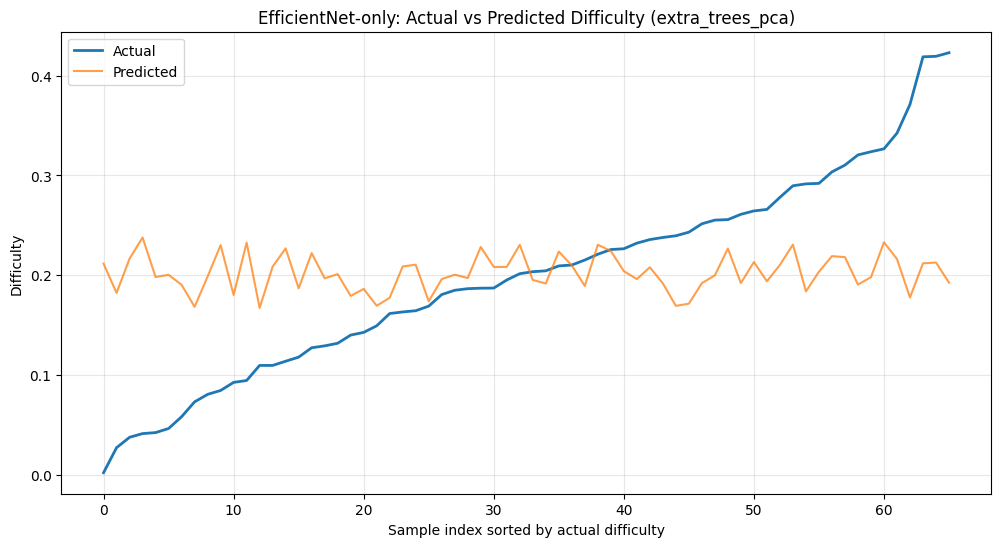

In [7]:
plot_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(plot_df["Actual"].values, label="Actual", linewidth=2)
plt.plot(plot_df["Predicted"].values, label="Predicted", alpha=0.75)
plt.title(f"EfficientNet-only: Actual vs Predicted Difficulty ({best_model_name})")
plt.xlabel("Sample index sorted by actual difficulty")
plt.ylabel("Difficulty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()